In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd

import numpy as np
import seaborn as sns

import math
import plotly.express as px

In [2]:
image_descriptions = []
image_description_files = utils.get_files_in_directory("../../Data/STEREO_VIEWS/DESCRIPTIONS/")
for f in image_description_files:
    image_descriptions.append(utils.read_file(f))

In [3]:
import google.generativeai as genai

genai.configure(api_key=utils.API_KEY())
model = genai.GenerativeModel('gemini-1.5-flash')

In [4]:
topics = utils.get_list_topics()

In [5]:
def create_probability_distribution_prompt_photo(caption, topic, document):
    prompt = "The following document is the description of a photograph captioned '" + caption + "'."
    if topic == "Photography and Imaging":
        prompt += "Your task will be to judge whether the subject or scene depicted represents a person or people posing for a photograph."
    else:
        prompt += " Your task will be to judge whether the subject or scene depicted in the photograph is related to the given topic."
        prompt += "\nDOCUMENT : {" + document + "}\nTOPIC : " + topic +  "\n"
    prompt += """
    Your response should be of the form 'Y' if you believe that the document belongs to the topic, and 'N' otherwise. Please provide no other commentary in your response."""
    return prompt

In [6]:
sentence_folders = utils.get_folders_in_folder("../../Data/TEXT/ALL_SENTENCES/")
all_captions = []
for folder in sentence_folders:
    all_paragraphs = utils.get_files_in_directory(folder + "/")
    first_paragraph = utils.read_file(all_paragraphs[0])
    caption = first_paragraph.split("\n")[0]
    if caption[0].isdigit():
        caption = ".".join(caption.split(".")[1:])
    all_captions.append(caption)

In [7]:
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def get_prob_distribution_images():
    all_rows = []
    for image, caption in tqdm(zip(image_descriptions, all_captions)):
        this_row = []
        for topic in topics:
            prompt = create_probability_distribution_prompt_photo(caption, topic, image)
            response = model.generate_content(
            contents=[
                prompt])
            logprob = response.candidates[0].avg_logprobs
            if response.text[0] == "N":
                logprob = 1000 + logprob
            elif response.text[0] != "Y":
                print(response.text)
                raise SyntaxError
            if response.text[1] != "\n":
                print(response.text)
                raise SyntaxError
            this_row.append(logprob)
        all_rows.append(this_row)
    return all_rows

In [8]:
all_rows = get_prob_distribution_images()

100it [20:44, 12.45s/it]


In [11]:
topic_probs_final = pd.DataFrame(all_rows, columns = topics)

In [ ]:
import math

## calculate true probability from log prob
def get_prob_from_log_prob(x):
    inverse = False
    if x > 100:
        x -= 1000
        inverse = True
    p = math.exp(2*x)
    if(inverse):
        p = 1 - p
    return p

func = np.vectorize(get_prob_from_log_prob)
res = func(topic_probs_final.to_numpy())

probs = pd.DataFrame(data=res, columns = topic_probs_final.columns)
probs.to_csv("../../Data/TOPIC_MODELLING/PROBABILITY_DISTRIBUTION/images.csv", index=False)

In [19]:
def l1_norm(matrix):
    row_sums = np.sum(matrix, axis=1, keepdims=True)
    normalized_matrix = np.copy(matrix).astype(float)
    row_sums_safe = np.where(row_sums == 0, 1, row_sums)
    normalized_matrix = normalized_matrix / row_sums_safe
    return normalized_matrix

res = l1_norm(probs.to_numpy())
probs = pd.DataFrame(data=res, columns = probs.columns)

In [21]:
topics = utils.get_list_topics()
topic_to_id = dict()
for i, topic in enumerate(topics):
    topics[i] = topic
    
id_to_topic = {v: k for k, v in topic_to_id.items()}
id_to_topic = dict(sorted(id_to_topic.items()))

In [22]:
max_categories = 5
min_value = 0.05

In [23]:
def get_sentence_categories(row, max_categories):
    nlargest_index = list(row.nlargest(max_categories).index)
    nlargest_values = list(row.nlargest(max_categories))
    if nlargest_values[0] < min_value:
        return {"categories": [], "categories_probs":[]}
    chosen_cats = []
    values = []
    for i, index in enumerate(nlargest_index):
        if(nlargest_values[i] > min_value):
            chosen_cats.append(index)
            values.append(nlargest_values[i])
    return {"categories": chosen_cats, "categories_probs":values}
        

In [24]:
probs_applied = probs.apply(lambda x : get_sentence_categories(x, max_categories), axis=1, result_type="expand")

In [25]:
probs_applied

,categories,categories_probs
0,"[Harbor and Waterways, British Colonialism, Tr...","[0.13306877541416887, 0.13306860093450754, 0.1..."
1,"[Harbor and Waterways, Geography and Topograph...","[0.14292729226385525, 0.14292724114284192, 0.1..."
2,"[Harbor and Waterways, Daily Life and Occupati...","[0.1114466961304801, 0.11144668284337765, 0.11..."
3,"[Harbor and Waterways, Daily Life and Occupati...","[0.14110143282833892, 0.14109993592288197, 0.1..."
4,"[Architecture and Building, Geography and Topo...","[0.49999085101228186, 0.4999624808437444]"
...,...,...
95,[Architecture and Building],[0.9998826049821822]
96,"[Social Classes and Customs, Transportation, P...","[0.17309618859446635, 0.1730961060553289, 0.17..."
97,"[Photography and Imaging, War and Conflict, So...","[0.20176117883387865, 0.20175882189001632, 0.2..."
98,"[Photography and Imaging, Social Classes and C...","[0.29518242591817284, 0.2951726443010741, 0.29..."


In [27]:
probs_applied["length_cats"] = probs_applied["categories"].apply(lambda x : len(x))
c = probs_applied.groupby("length_cats")["categories"].count()

In [28]:
data = pd.DataFrame(zip(c.index, c.values), columns=["Cats", "Num"])

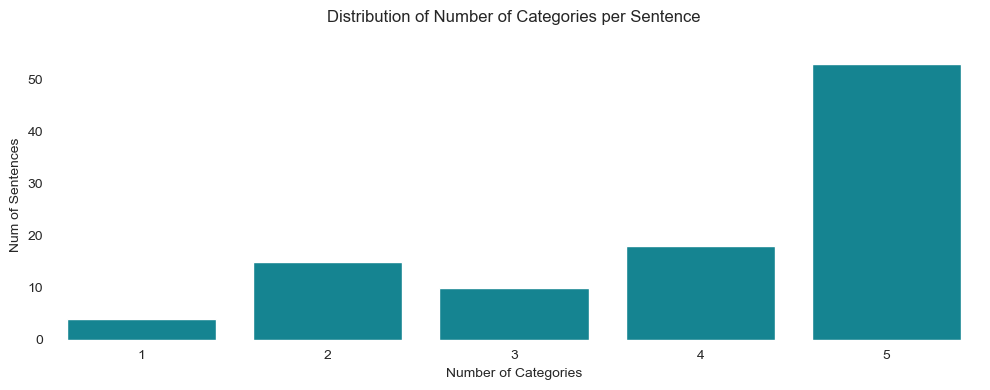

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Cats', y='Num', data=data,
                 color='#0094a6') 

plt.xlabel('Number of Categories') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Sentences')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Distribution of Number of Categories per Sentence', pad=20)

plt.tight_layout()
plt.show()

In [30]:
probs_applied.to_csv("../../Data/ALL_IMAGES_CLASSED.csv")

In [4]:
probs_applied = pd.read_csv("../../Data/ALL_IMAGES_CLASSED.csv", index_col=0)

In [7]:
probs_applied.to_csv("ALL_IMAGES_CLASSED.csv", sep=";", index=False)